In [1]:
from src.ArtifficialTrainDataGenerator2 import ArtifficialTrainDataGenerator2 
import matplotlib.pyplot as plt
import numpy as np


X, y = ArtifficialTrainDataGenerator2.generate_artificial_data(250000, mu_max_err=0.05, mu_max_err_global=0.1, sigma_range=(0.2, 0.8), set_percentages=True, cache_element_samples=False)


100%|██████████| 50/50 [00:00<00:00, 506558.45it/s]


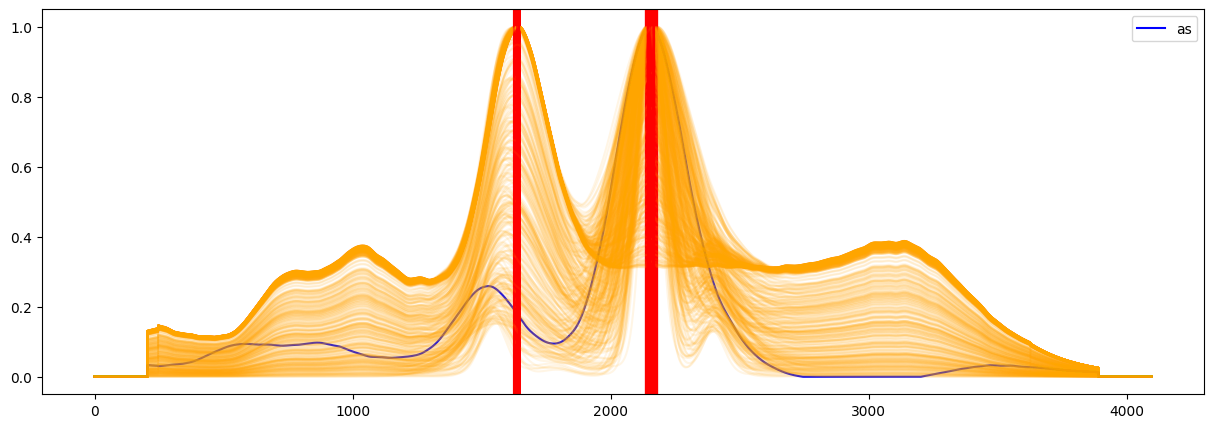

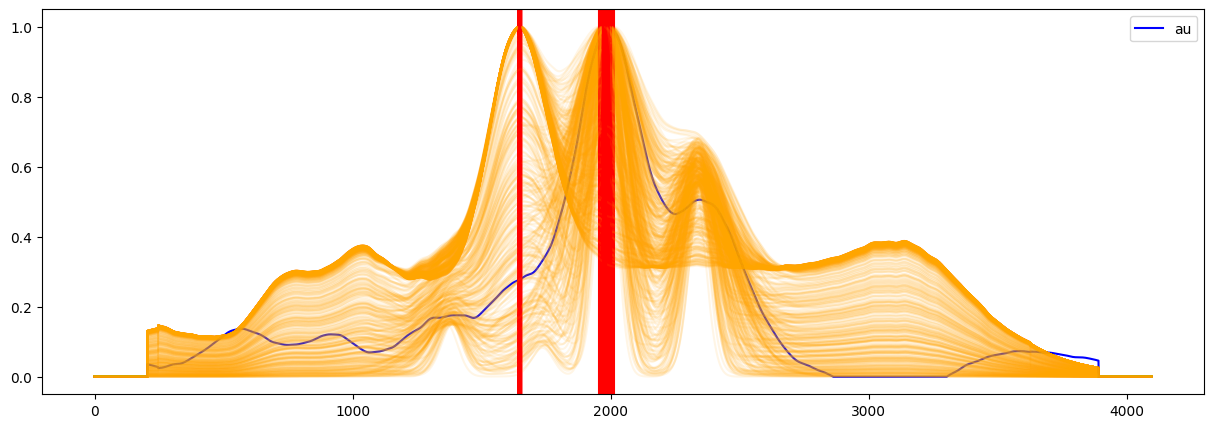

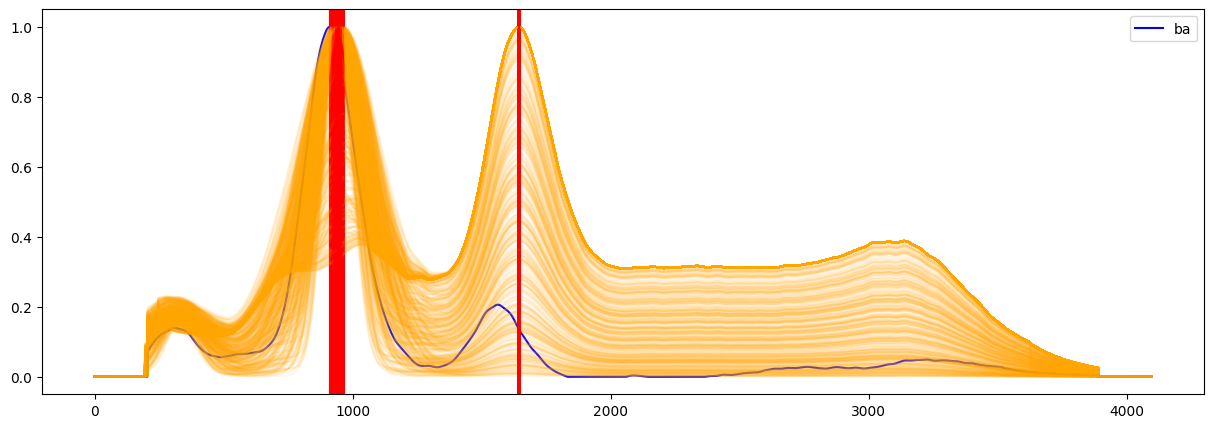

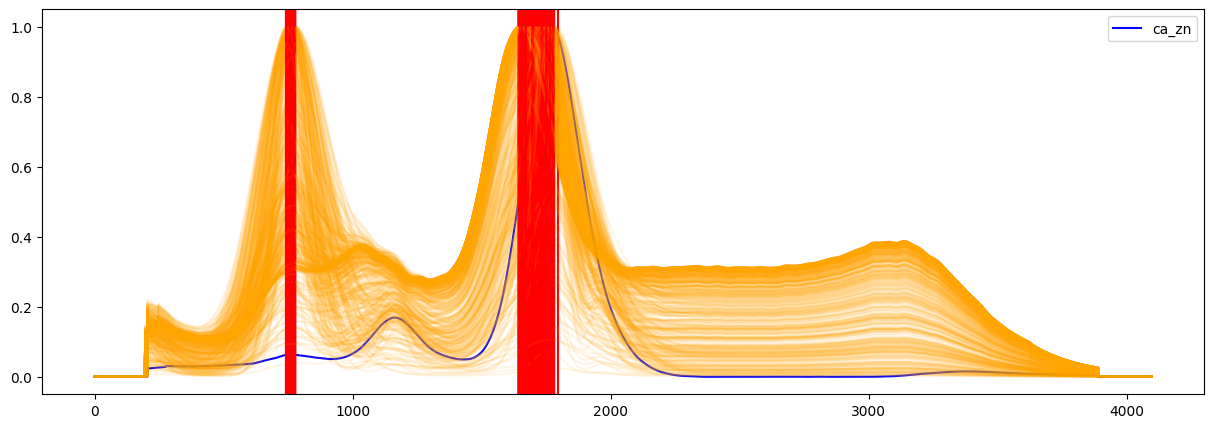

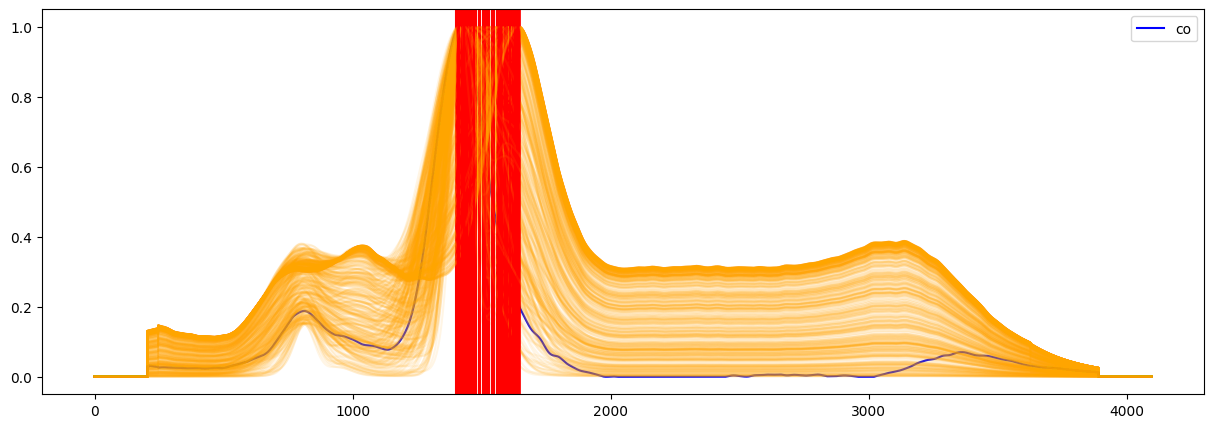

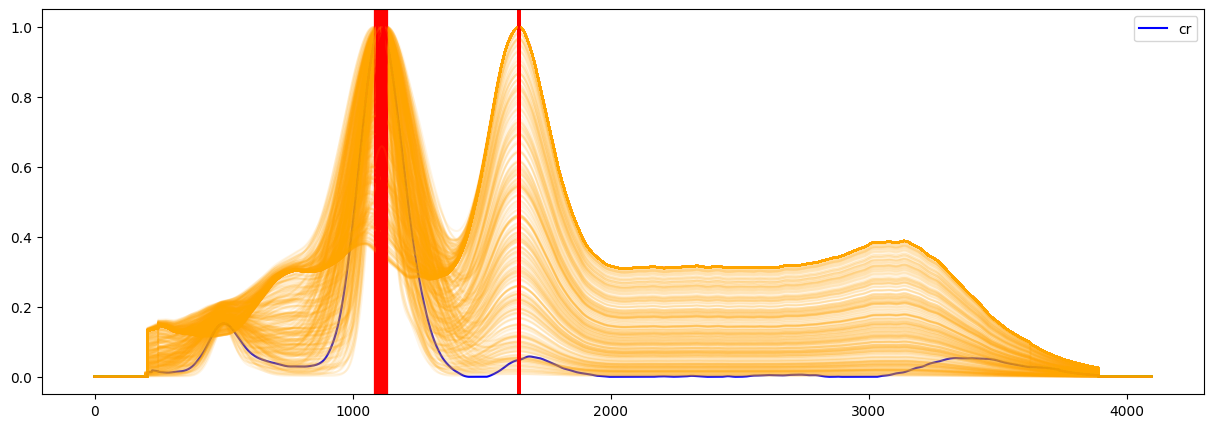

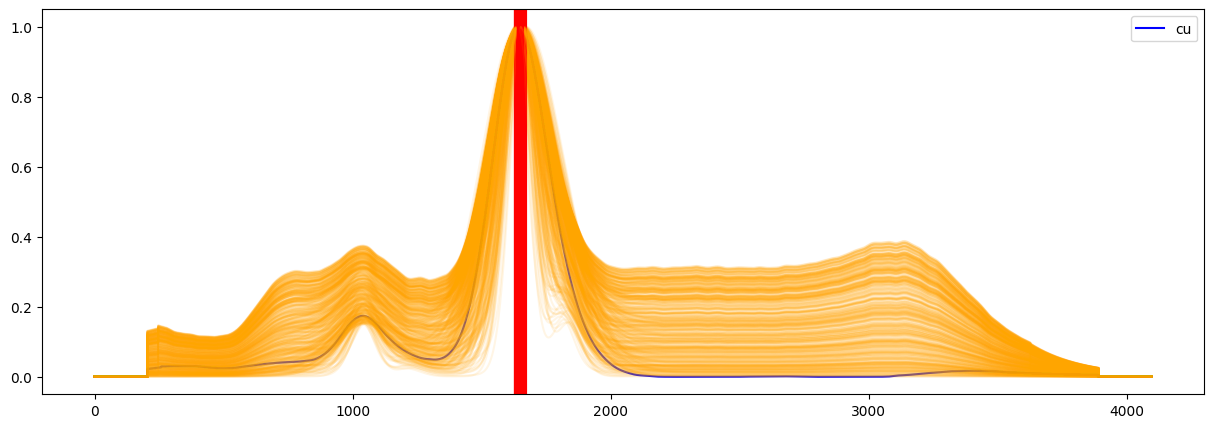

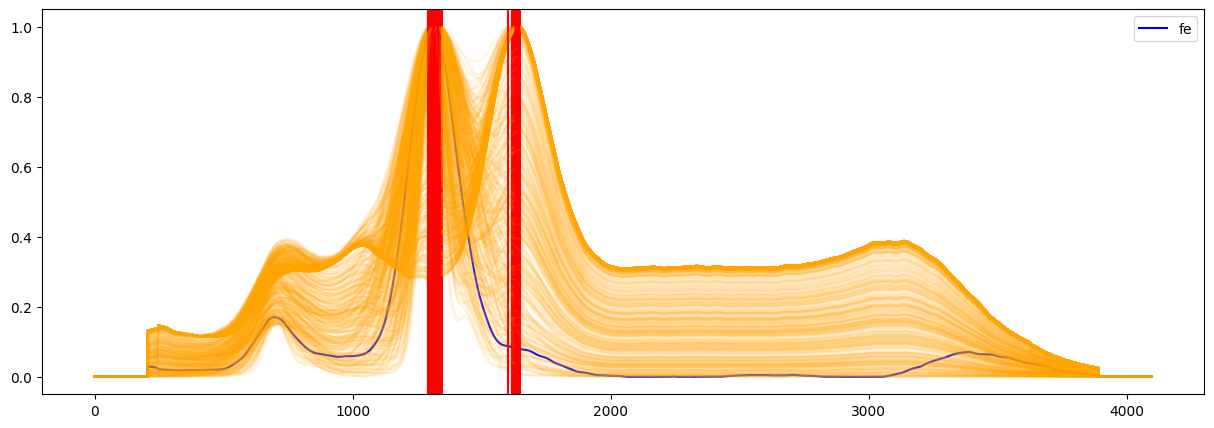

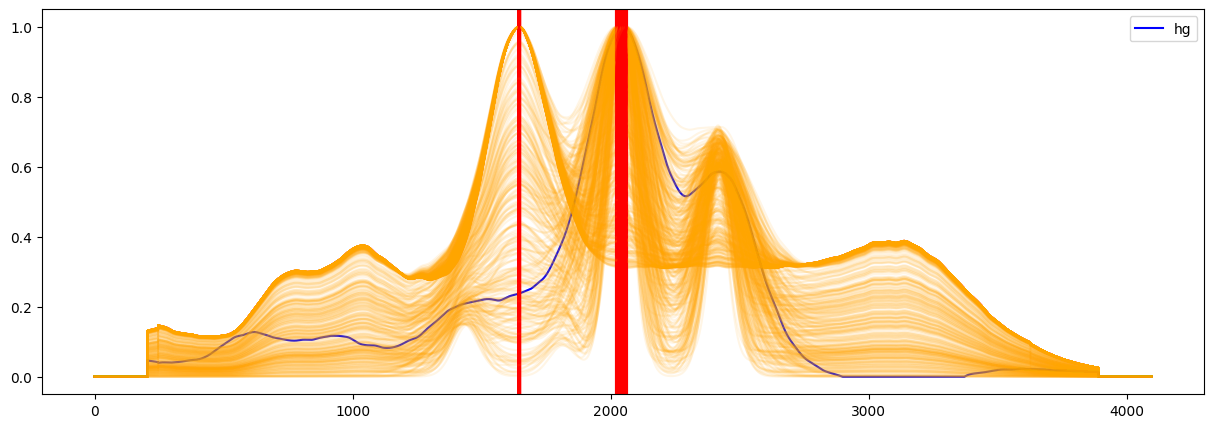

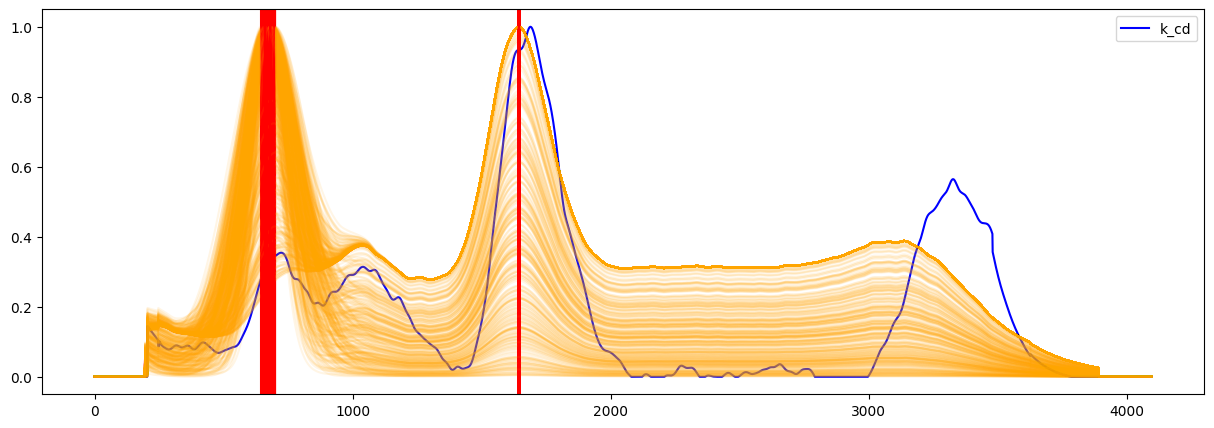

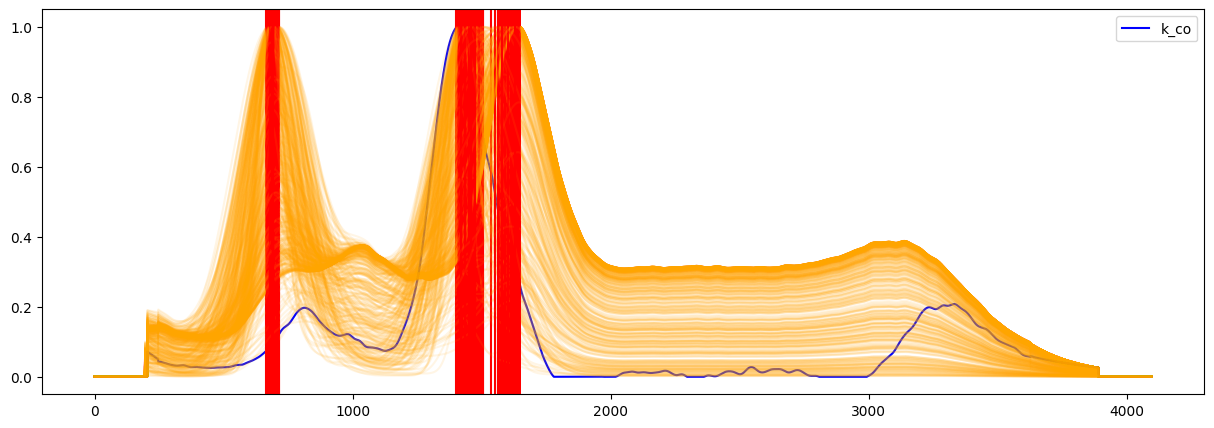

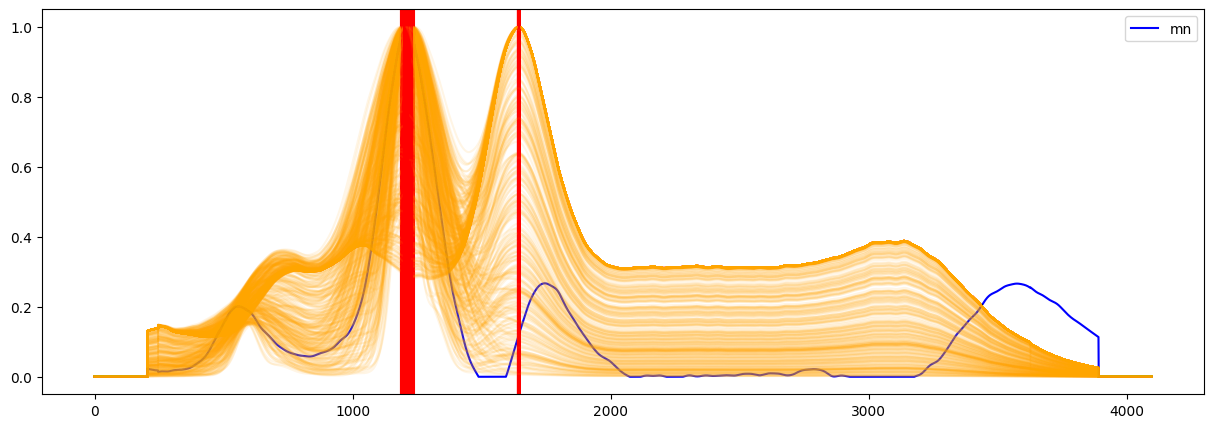

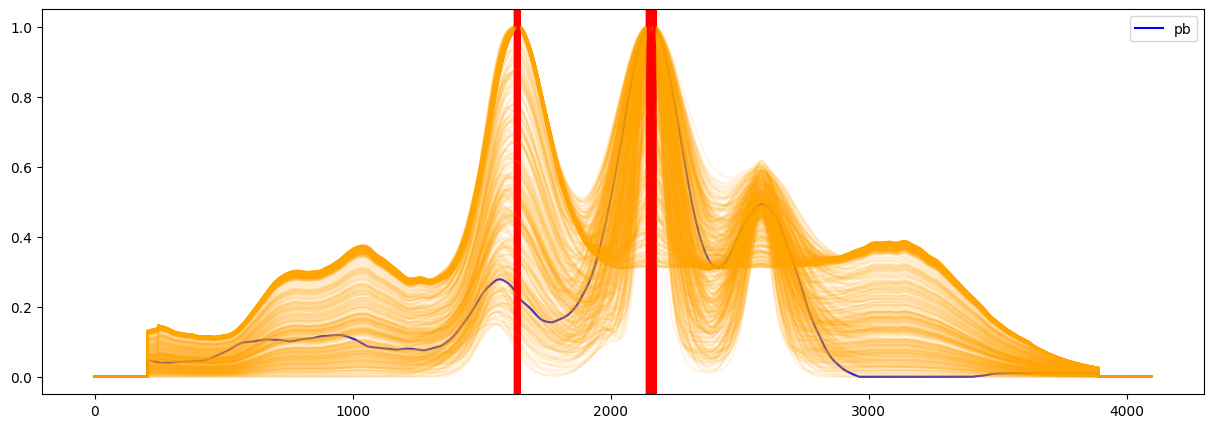

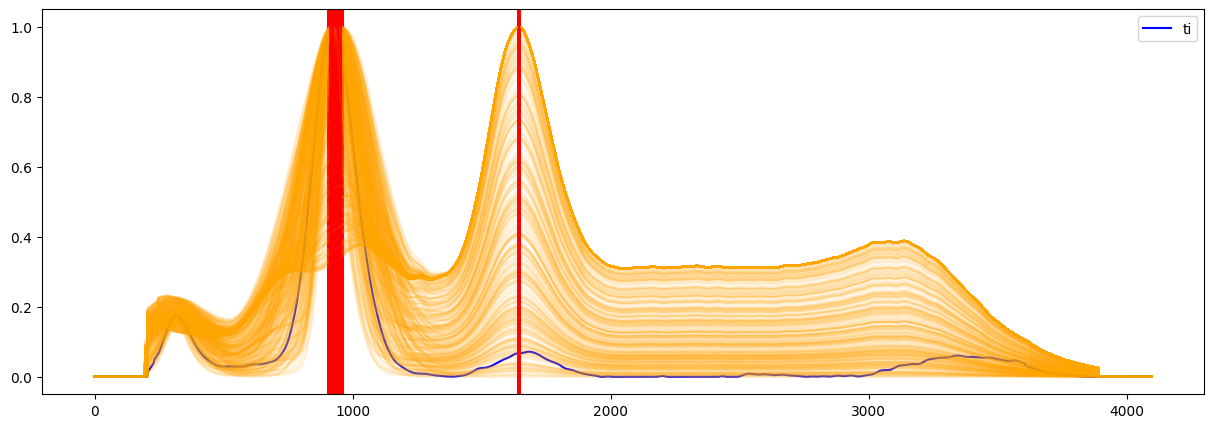

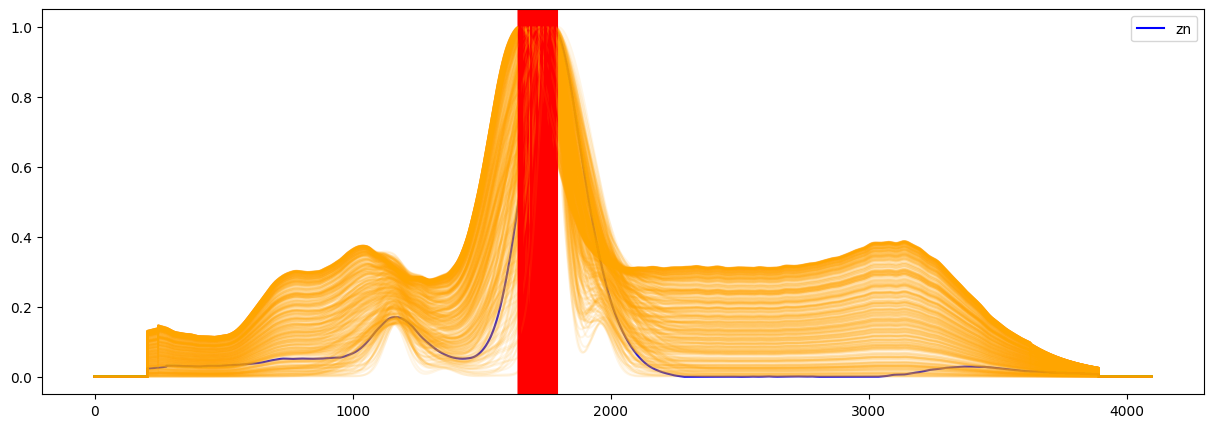

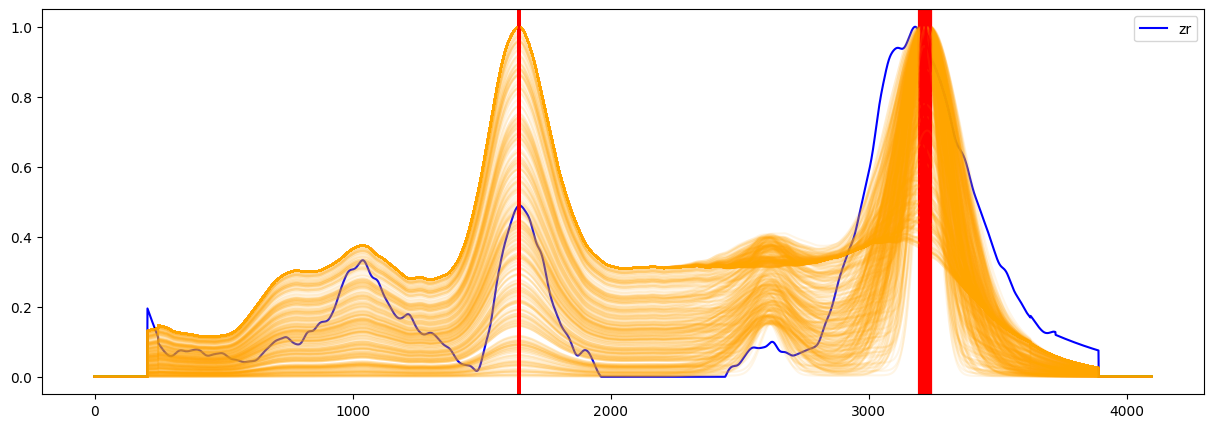

In [2]:
from src import Elements
import random

calibrated_spectra = np.load("data/objects/pigment_palette/2_subtracted_residual_spectra_heuristic.npz", allow_pickle=True)

for name, spectrum in calibrated_spectra.items(): 
    plt.figure(random.randint(1, int(10e10)), figsize=(15, 5))
    elements = name.split("_")
    if name == "wood":
        continue
    XX, _= ArtifficialTrainDataGenerator2.generate_many_samples(500, mu_max_err=0.05, mu_max_err_global=0.05, sigma_range=(0.2, 0.7), elements=elements, set_percentages=True, cache_element_samples=False)

    plt.plot(spectrum, color="blue", label=name)
    for spectrum in XX:
        plt.plot(spectrum, color="orange", alpha=0.1)
        plt.axvline(np.argmax(spectrum), color="red")
    plt.legend()
    
    

In [3]:
from src.FeatureEnhancer import FeatureEnhancer

X = FeatureEnhancer.process_spectra(np.array(X))

100%|██████████| 51/51 [00:00<00:00, 417792.00it/s]


/tmp/ipykernel_423496/3557446954.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


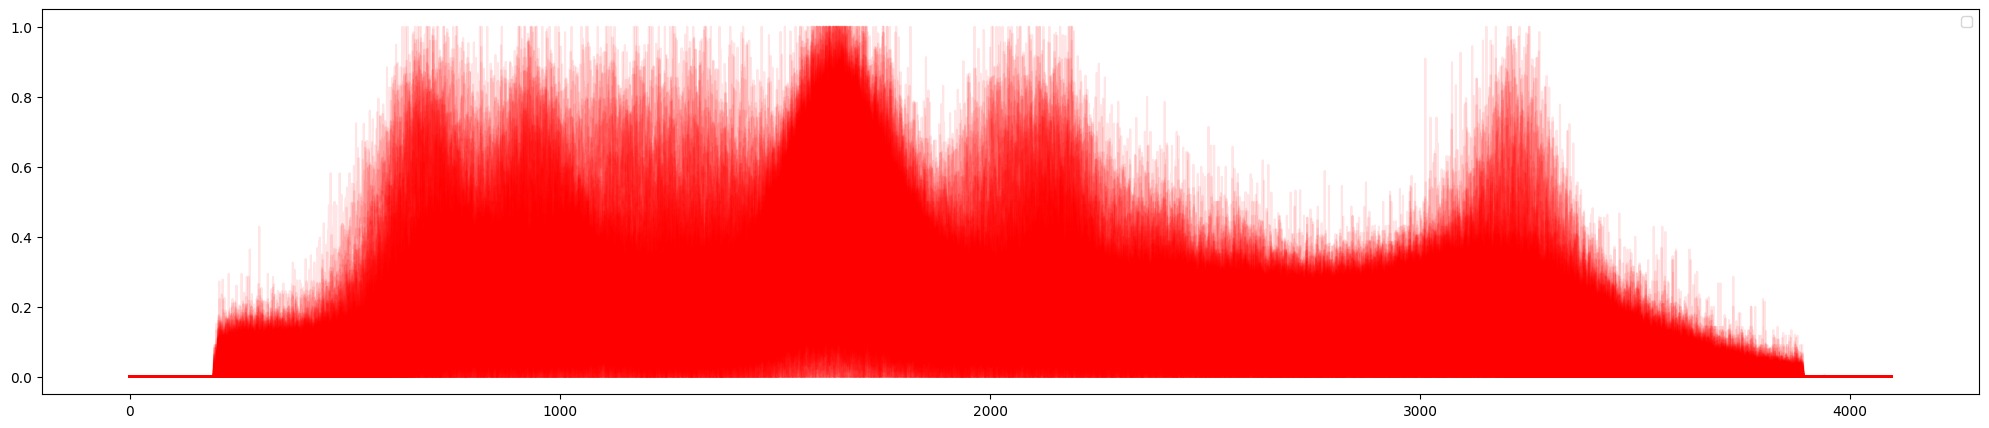

In [4]:
from random import randint
from src.Elements import Elements
import matplotlib.pyplot as plt
plt.figure(figsize=(25, 5))
for _ in range(250):
    i = randint(0, len(y)-1)
    label = ", ".join([f"{Elements.NUM2SYMBOL[j] if j < len(Elements.NUM2SYMBOL) else "wood"}:{np.round(el, 2)}" for j, el in enumerate(y[i]) if el > 0])

    plt.plot( X[i], color="red", alpha=0.1)
    # plt.axvline(np.argmax(X[i]))
    
plt.legend()

In [5]:
from datetime import datetime
np.save(f"data/training_data/artificial/X_regression_{datetime.now().strftime("%Y%m%d_%H%M%S")}.npy", X)
np.save(f"data/training_data/artificial/y_regression_{datetime.now().strftime("%Y%m%d_%H%M%S")}.npy", y)

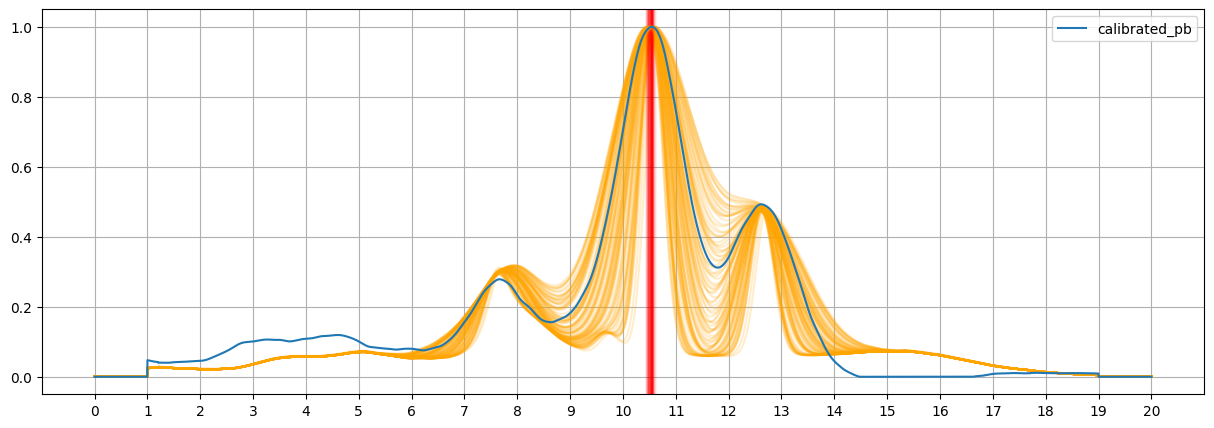

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from src.Elements import Elements
import random

energy_range = np.linspace(0, 20, 4096)
wood_spectrum = np.load("data/objects/pigment_palette/1_calibrated_spectra.npz", allow_pickle=True)["wood"]
calibrated_spectra = np.load("data/objects/pigment_palette/2_subtracted_residual_spectra_heuristic.npz", allow_pickle=True)

for spectrum_name, spectrum in calibrated_spectra.items():
    if spectrum_name == "wood" or spectrum_name != "pb":
        continue

    artificial = np.zeros_like(energy_range)

    plt.figure(figsize=(15, 5))
    for element_name in spectrum_name.split("_"):
        for scale in np.linspace(0.2, 0.8, 100):
            artificial += ArtifficialTrainDataGenerator2._generate_element_sample(np.linspace(0, 20, 4096), element_name, mu_err_global=random.random()/10 * (-1 if random.random() < 0.5 else 1), mu_max_err=random.random()/20, sigma=scale, cache_element_samples=False)

            artificial += wood_spectrum * 0.2
            artificial /= np.max(artificial)
            plt.plot(energy_range, artificial, color="orange", alpha=0.2)
            plt.axvline(np.argmax(artificial) / (4096) * 20, color="red", alpha=0.05)
    plt.plot(energy_range, spectrum, label=f"calibrated_{spectrum_name}")
    plt.xticks(np.arange(0, 21, 1))
    plt.legend()
    plt.grid(True)